In [1]:
!pip install -q datasets


In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
queries = load_dataset(
    "milistu/amazon-esci-data",
    "queries",
    split="train"
)

README.md:   0%|          | 0.00/5.77k [00:00<?, ?B/s]

queries/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 47.9MB            

queries/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

queries/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 15.7MB            

queries/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1983272 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/638016 [00:00<?, ? examples/s]

In [4]:
queries_small = queries.shuffle(seed=42).select(range(100000))

In [5]:
df = queries_small.to_pandas()

In [6]:
df.shape

(100000, 10)

In [7]:
df.head()

,example_id,query,query_id,product_id,product_locale,esci_label,small_version,large_version,split,__index_level_0__
0,1942124,support plus,99432,B00WIY97S2,us,S,0,1,train,1942124
1,1499389,origins mask,76265,B01FSDU98G,es,E,0,1,train,1499389
2,711836,dress shirts for men,35435,B01M1K82SZ,us,E,0,1,train,711836
3,238069,athletic socks low cut for women,10954,B083XP9ZWW,us,E,1,1,train,238069
4,2423622,フコイダン,122766,B072VKNHW3,jp,E,0,1,train,2423622


In [8]:
df.columns

Index(['example_id', 'query', 'query_id', 'product_id', 'product_locale',
       'esci_label', 'small_version', 'large_version', 'split',
       '__index_level_0__'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   example_id         100000 non-null  int64 
 1   query              100000 non-null  object
 2   query_id           100000 non-null  int64 
 3   product_id         100000 non-null  object
 4   product_locale     100000 non-null  object
 5   esci_label         100000 non-null  object
 6   small_version      100000 non-null  int64 
 7   large_version      100000 non-null  int64 
 8   split              100000 non-null  object
 9   __index_level_0__  100000 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 7.6+ MB


In [10]:
df["esci_label"].value_counts()

,count
esci_label,
E,66464
S,21244
I,9572
C,2720


In [11]:
df["product_locale"].value_counts()

,count
product_locale,
us,70087
jp,16663
es,13250


In [12]:
df = df[df["product_locale"] == "us"].copy()

In [13]:
df["esci_label"].value_counts()

,count
esci_label,
E,48998
S,13748
I,5921
C,1420


In [14]:
df[["query", "product_id", "esci_label"]].head(20)

,query,product_id,esci_label
0,support plus,B00WIY97S2,S
2,dress shirts for men,B01M1K82SZ,E
3,athletic socks low cut for women,B083XP9ZWW,E
5,starbucks outfit women,B0056ZS0C4,S
6,vinvent price,B002YMFVBA,I
8,bath towels,B0857GD433,E
9,enya cds,B000026HBQ,E
10,jeans for women yellow,B07RC9LKTN,E
11,cargador iphone de 3,B082YN8RYV,I
12,keto sweets cookbook,1092594906,E


In [15]:
products = load_dataset(
    "milistu/amazon-esci-data",
    "products",
    split="train"
)

products/train-00000-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  222MB            

products/train-00000-of-00004.parquet: downloading bytes:           |  0.00B            

products/train-00001-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  220MB            

products/train-00001-of-00004.parquet: downloading bytes:           |  0.00B            

products/train-00002-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  203MB            

...

products/test-00000-of-00002.parquet: downloading bytes:           |  0.00B            

products/test-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  139MB            

products/test-00001-of-00002.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1371823 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/443101 [00:00<?, ? examples/s]

In [16]:
product_ids = set(df["product_id"].unique())

print("Unique products needed:", len(product_ids))

Unique products needed: 67354


In [17]:
products_needed = products.filter(
    lambda x: x["product_id"] in product_ids
)

Filter:   0%|          | 0/1371823 [00:00<?, ? examples/s]

In [18]:
products_df = products_needed.to_pandas()

In [19]:
products_df.shape

(63353, 9)

In [20]:
products_df.head()

,product_id,product_title,product_description,product_bullet_point,product_brand,product_color,product_locale,split,__index_level_0__
0,B00NHYPQQO,A Series Of Unfortunate Events Lemony Snicket ...,Will be dispatched from the UK. Brand new copy.,None,None,None,es,train,131
1,B009SZ2PTM,Utopia Towels - 2 alfombras de baño de algodón...,<p> <strong> ¡Obtenga el mayor valor por su di...,No utilice blanqueadores ni suavizantes de tel...,Utopia Towels,Gris,es,train,2384
2,B00LB7REFK,trtl Pillow - Almohada de Viaje con Soporte pa...,<p><b>Trtl Pillow</b> es la almohada de viaje ...,Almohada con soporte para el cuello para viaje...,trtl,Gris,es,train,2641
3,B004M3PS4O,"ClevaMama Almohada para niños con ClevaFoam, t...",None,Lujosa almohada para niños: perfecta para niño...,Clevamama,Almohada,es,train,2666
4,B01687MKAG,Victoria's Secret Aqua Kiss Fragrance Mist Col...,None,Tipo de producto: Colonia\nMarca: Victoria's S...,Victoria's Secret,None,es,train,3764


In [21]:
products_df.columns

Index(['product_id', 'product_title', 'product_description',
       'product_bullet_point', 'product_brand', 'product_color',
       'product_locale', 'split', '__index_level_0__'],
      dtype='object')

In [22]:
final_df = df.merge(
    products_df,
    on="product_id",
    how="inner"
)

In [23]:
final_df.shape

(65767, 18)

In [24]:
final_df[
    [
        "query",
        "product_id",
        "product_title",
        "product_description",
        "esci_label"
    ]
].head(10)

,query,product_id,product_title,product_description,esci_label
0,support plus,B00WIY97S2,"Powerstep Pinnacle Plus Insoles, Built in Meta...",None,S
1,dress shirts for men,B01M1K82SZ,Kenneth Cole Unlisted Men's Dress Shirt Slim F...,None,E
2,athletic socks low cut for women,B083XP9ZWW,New Balance Women's Athletic Arch Compression ...,<p><b>New Balance Womens Athletic Low Cut Sock...,E
3,starbucks outfit women,B0056ZS0C4,"Nike Golf Tech Visor, White, Adjustable",The Nike Tech Tour Adjustable Golf Visorfeatur...,S
4,vinvent price,B002YMFVBA,Murders in the Rue Morgue,None,I
5,bath towels,B0857GD433,Xisheep 1PC Towel Shower Absorbent Superfine F...,1PC Towel Shower Absorbent Superfine Fiber Sof...,E
6,enya cds,B000026HBQ,Shepherd Moons,Smash 1991 album from the Irish institution! F...,E
7,jeans for women yellow,B07RC9LKTN,YELETE Women's Basic Five Pocket Stretch Jeggi...,These jeggings are styled to resemble a pair o...,E
8,cargador iphone de 3,B082YN8RYV,"Seneo Wireless Charger, 3 in 1 Wireless Chargi...",None,I
9,keto sweets cookbook,1092594906,"Keto Desserts Cookbook #2019: Mouth-Watering, ...",None,E


In [25]:
final_df.isnull().sum()

,0
example_id,0
query,0
query_id,0
product_id,0
product_locale_x,0
esci_label,0
small_version,0
large_version,0
split_x,0
__index_level_0___x,0


In [26]:
final_df["product_text"] = (
    final_df["product_title"].fillna("") + " " +
    final_df["product_description"].fillna("") + " " +
    final_df["product_bullet_point"].fillna("") + " " +
    final_df["product_brand"].fillna("")
)

In [27]:
final_df[
    ["query", "product_text", "esci_label"]
].head()

,query,product_text,esci_label
0,support plus,"Powerstep Pinnacle Plus Insoles, Built in Meta...",S
1,dress shirts for men,Kenneth Cole Unlisted Men's Dress Shirt Slim F...,E
2,athletic socks low cut for women,New Balance Women's Athletic Arch Compression ...,E
3,starbucks outfit women,"Nike Golf Tech Visor, White, Adjustable The Ni...",S
4,vinvent price,Murders in the Rue Morgue,I


In [28]:
final_df.isnull().sum()

,0
example_id,0
query,0
query_id,0
product_id,0
product_locale_x,0
esci_label,0
small_version,0
large_version,0
split_x,0
__index_level_0___x,0


In [29]:
final_df[["query", "product_text", "esci_label"]].isnull().sum()

,0
query,0
product_text,0
esci_label,0


In [30]:
final_df.duplicated().sum()

np.int64(0)

In [31]:
final_df.duplicated(
    subset=["query", "product_id"]
).sum()

np.int64(1076)

In [32]:
final_df["esci_label"].value_counts()

,count
esci_label,
E,46031
S,12846
I,5557
C,1333


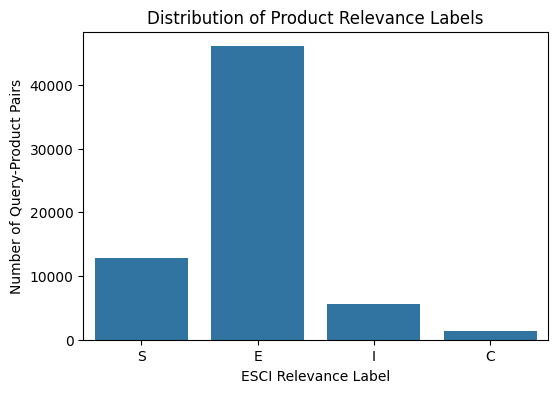

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=final_df,
    x="esci_label"
)

plt.title("Distribution of Product Relevance Labels")
plt.xlabel("ESCI Relevance Label")
plt.ylabel("Number of Query-Product Pairs")

plt.show()

In [34]:
final_df["query_length"] = (
    final_df["query"]
    .str.split()
    .str.len()
)

In [35]:
final_df["query_length"].describe()

,query_length
count,65767.000000
mean,3.570894
std,1.704776
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,29.000000


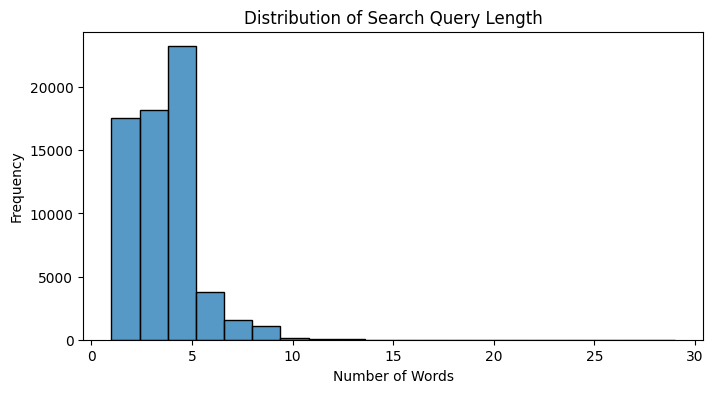

In [36]:
plt.figure(figsize=(8,4))

sns.histplot(
    final_df["query_length"],
    bins=20
)

plt.title("Distribution of Search Query Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [37]:
final_df["query"].value_counts().head(20)

,count
query,
tv,11
ipad,11
laptop,11
lol dolls,9
porsche black touch up paint,8
airpods,8
bose soundsport wireless headphones,8
minute maid pink lemonade,8
exercise mat,8


In [38]:
final_df["product_text_length"] = (
    final_df["product_text"]
    .str.split()
    .str.len()
)

In [39]:
final_df["product_text_length"].describe()

,product_text_length
count,65767.000000
mean,183.617133
std,154.800847
min,1.000000
25%,56.000000
50%,141.000000
75%,278.000000
max,910.000000


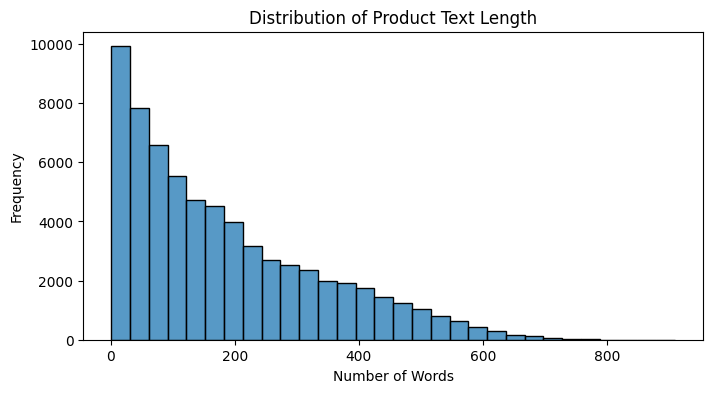

In [40]:
plt.figure(figsize=(8,4))

sns.histplot(
    final_df["product_text_length"],
    bins=30
)

plt.title("Distribution of Product Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [41]:
duplicate_pairs = final_df[
    final_df.duplicated(
        subset=["query", "product_id"],
        keep=False
    )
].sort_values(["query", "product_id"])

duplicate_pairs[
    ["query", "product_id", "esci_label"]
].head(20)

,query,product_id,esci_label
7012,$10 lol literally not gonna change baby pet lol,B07XSPCBVP,E
7013,$10 lol literally not gonna change baby pet lol,B07XSPCBVP,E
7014,$10 lol literally not gonna change baby pet lol,B07XSPCBVP,E
46906,$2 pop tube not a pack,B07MBW6JNL,E
46907,$2 pop tube not a pack,B07MBW6JNL,E
39718,$20 off for amazon app not applied,B01ITAKG6A,I
39719,$20 off for amazon app not applied,B01ITAKG6A,I
49112,$20 vr headset without controller,B07PTMKYS7,I
49113,$20 vr headset without controller,B07PTMKYS7,I
49114,$20 vr headset without controller,B07PTMKYS7,I


In [42]:
duplicate_label_check = (
    duplicate_pairs
    .groupby(["query", "product_id"])["esci_label"]
    .nunique()
)

duplicate_label_check.value_counts()

,count
esci_label,
1,985


In [43]:
final_df["esci_label"].value_counts()

,count
esci_label,
E,46031
S,12846
I,5557
C,1333


In [44]:
final_df["esci_label"].value_counts(normalize=True) * 100

,proportion
esci_label,
E,69.991029
S,19.532592
I,8.449526
C,2.026852


In [45]:
final_df["query_length"] = (
    final_df["query"]
    .str.split()
    .str.len()
)

In [46]:
final_df["query_length"].describe()

,query_length
count,65767.000000
mean,3.570894
std,1.704776
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,29.000000


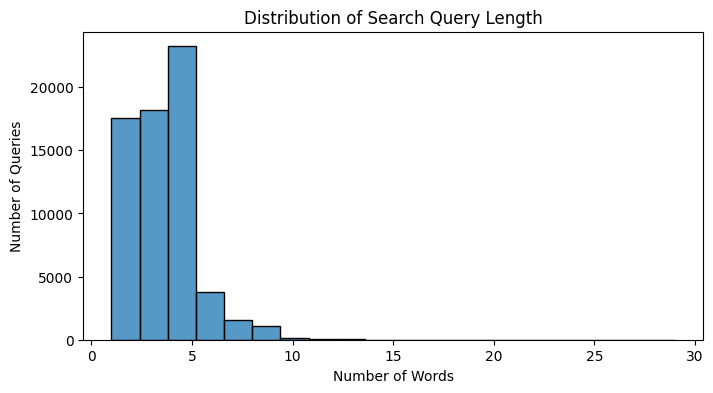

In [47]:
plt.figure(figsize=(8,4))

sns.histplot(
    final_df["query_length"],
    bins=20
)

plt.title("Distribution of Search Query Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Queries")

plt.show()

In [48]:
final_df["query"].value_counts().head(20)

,count
query,
tv,11
ipad,11
laptop,11
lol dolls,9
porsche black touch up paint,8
airpods,8
bose soundsport wireless headphones,8
minute maid pink lemonade,8
exercise mat,8


In [49]:
final_df["product_text_length"] = (
    final_df["product_text"]
    .str.split()
    .str.len()
)

In [50]:
final_df["product_text_length"].describe()

,product_text_length
count,65767.000000
mean,183.617133
std,154.800847
min,1.000000
25%,56.000000
50%,141.000000
75%,278.000000
max,910.000000


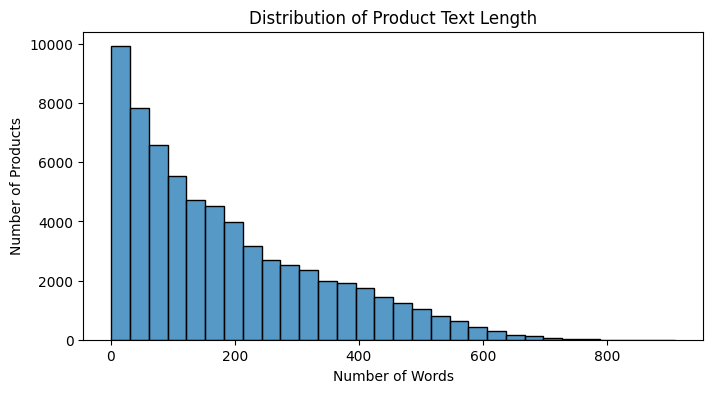

In [51]:
plt.figure(figsize=(8,4))

sns.histplot(
    final_df["product_text_length"],
    bins=30
)

plt.title("Distribution of Product Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Products")

plt.show()

In [52]:
duplicate_pairs = final_df[
    final_df.duplicated(
        subset=["query", "product_id"],
        keep=False
    )
]

duplicate_pairs[["query", "product_id", "esci_label"]].head(20)

,query,product_id,esci_label
31,bose quietcomfort 35 ii,B07Q4QK379,S
32,bose quietcomfort 35 ii,B07Q4QK379,S
79,strapless bras for women,B07CSY1WHT,E
80,strapless bras for women,B07CSY1WHT,E
84,amazon basics iphone case xs white,B07H9PDLRF,I
85,amazon basics iphone case xs white,B07H9PDLRF,I
103,kidney cleanse,B01FERIHYE,E
104,kidney cleanse,B01FERIHYE,E
161,natural moisturizer for face,B01ES349CY,E
162,natural moisturizer for face,B01ES349CY,E


In [53]:
duplicate_label_check = (
    duplicate_pairs
    .groupby(["query", "product_id"])["esci_label"]
    .nunique()
)

duplicate_label_check.value_counts()

,count
esci_label,
1,985


In [54]:
final_df["esci_label"].value_counts()

,count
esci_label,
E,46031
S,12846
I,5557
C,1333


In [55]:
final_df["esci_label"].value_counts(normalize=True) * 100

,proportion
esci_label,
E,69.991029
S,19.532592
I,8.449526
C,2.026852


In [56]:
final_df["query_length"] = (
    final_df["query"]
    .str.split()
    .str.len()
)

final_df["query_length"].describe()

,query_length
count,65767.000000
mean,3.570894
std,1.704776
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,29.000000


In [57]:
final_df["product_text_length"] = (
    final_df["product_text"]
    .str.split()
    .str.len()
)

final_df["product_text_length"].describe()

,product_text_length
count,65767.000000
mean,183.617133
std,154.800847
min,1.000000
25%,56.000000
50%,141.000000
75%,278.000000
max,910.000000


In [58]:
final_df = final_df.drop_duplicates(
    subset=["query", "product_id"]
).reset_index(drop=True)

In [59]:
final_df.shape

(64691, 21)

In [60]:
final_df.duplicated(
    subset=["query", "product_id"]
).sum()

np.int64(0)

In [61]:
final_df.to_csv(
    "esci_search_dataset.csv",
    index=False
)

In [62]:
import os

os.path.getsize("esci_search_dataset.csv") / (1024 * 1024)

152.51902103424072

In [ ]:
from google.colab import files

files.download("esci_search_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# SECTION 2 — TF-IDF SEARCH BASELINE

## Objective
Build a traditional keyword-based product search system
using TF-IDF and Cosine Similarity.

## Search Pipeline
User Query → TF-IDF → Cosine Similarity → Ranking → Top-K Products


In [63]:
# Import tools required for TF-IDF based search

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [64]:
# Create a catalogue containing one row per unique product

products_catalog = final_df[
    ["product_id", "product_text"]
].drop_duplicates(
    subset="product_id"
).reset_index(drop=True)

In [65]:
# Check the number of unique products

products_catalog.shape

(62405, 2)

In [66]:
# View a few products

products_catalog.head()

,product_id,product_text
0,B00WIY97S2,"Powerstep Pinnacle Plus Insoles, Built in Meta..."
1,B01M1K82SZ,Kenneth Cole Unlisted Men's Dress Shirt Slim F...
2,B083XP9ZWW,New Balance Women's Athletic Arch Compression ...
3,B0056ZS0C4,"Nike Golf Tech Visor, White, Adjustable The Ni..."
4,B002YMFVBA,Murders in the Rue Morgue


In [67]:
# Create the TF-IDF vectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=50000
)

In [68]:
# Learn TF-IDF from the product catalogue
# and convert every product into a numerical vector

product_vectors = vectorizer.fit_transform(
    products_catalog["product_text"]
)

In [69]:
# Example user search query

user_query = "comfortable running shoes"

# Convert the query into a TF-IDF vector
query_vector = vectorizer.transform([user_query])

In [70]:
# Calculate similarity between the query and every product

similarity_scores = cosine_similarity(
    query_vector,
    product_vectors
)

In [71]:
# Check the similarity matrix shape

similarity_scores.shape

(1, 62405)

In [72]:
# Get the indices of products sorted by similarity
# from highest score to lowest score

ranked_indices = similarity_scores[0].argsort()[::-1]

In [73]:
# Select the top 10 most similar products

top_k = 10

top_indices = ranked_indices[:top_k]

In [74]:
# Display the top 10 search results

search_results = products_catalog.iloc[top_indices].copy()

search_results["similarity_score"] = (
    similarity_scores[0][top_indices]
)

search_results

,product_id,product_text,similarity_score
7575,B07BL314FY,"New Balance Women's 520 V5 Running Shoe, Black...",0.582693
55644,B07Y8KHTLJ,Medium Chunky Heel Short Boots-RQWEIN Women's ...,0.576752
28288,B07BL2TPBW,"New Balance Men's 520 V5 Running Shoe, Castler...",0.575784
26472,B01C4J7A02,ja vie Walking Shoes for Women Ballet Flats St...,0.495825
41485,B07PKYXV5J,New Balance Women's Fresh Foam Roav Trail V1 S...,0.484751
48405,B00V88DMKI,"Nike Men's Flex Experience Run 8 Shoe, Black/W...",0.456784
23193,B07FKDHK2V,"Nike Men's Flex Experience Run 8 Shoe, Black/W...",0.456753
29058,B07RSP6SQG,Men's Lace-Up Canvas Casual Shoes Breathable S...,0.454207
59399,B07H7YW9QX,"Nike Women's Downshifter 9 Sneaker, Anthracite...",0.453095
25591,B07TZQFFP5,GANNOU Women's Air Athletic Running Shoes Fash...,0.447659


In [75]:
user_query = "comfortable running shoes"

query_vector = vectorizer.transform([user_query])

In [76]:
similarity_scores = cosine_similarity(
    query_vector,
    product_vectors
)

similarity_scores.shape

(1, 62405)

In [77]:
ranked_indices = similarity_scores[0].argsort()[::-1]

top_k = 10
top_indices = ranked_indices[:top_k]

search_results = products_catalog.iloc[top_indices].copy()

search_results["similarity_score"] = (
    similarity_scores[0][top_indices]
)

search_results

,product_id,product_text,similarity_score
7575,B07BL314FY,"New Balance Women's 520 V5 Running Shoe, Black...",0.582693
55644,B07Y8KHTLJ,Medium Chunky Heel Short Boots-RQWEIN Women's ...,0.576752
28288,B07BL2TPBW,"New Balance Men's 520 V5 Running Shoe, Castler...",0.575784
26472,B01C4J7A02,ja vie Walking Shoes for Women Ballet Flats St...,0.495825
41485,B07PKYXV5J,New Balance Women's Fresh Foam Roav Trail V1 S...,0.484751
48405,B00V88DMKI,"Nike Men's Flex Experience Run 8 Shoe, Black/W...",0.456784
23193,B07FKDHK2V,"Nike Men's Flex Experience Run 8 Shoe, Black/W...",0.456753
29058,B07RSP6SQG,Men's Lace-Up Canvas Casual Shoes Breathable S...,0.454207
59399,B07H7YW9QX,"Nike Women's Downshifter 9 Sneaker, Anthracite...",0.453095
25591,B07TZQFFP5,GANNOU Women's Air Athletic Running Shoes Fash...,0.447659


In [78]:
def search_products(user_query, top_k=10):

    # Convert the user's query into a TF-IDF vector
    query_vector = vectorizer.transform([user_query])

    # Calculate similarity between query and all products
    similarity_scores = cosine_similarity(
        query_vector,
        product_vectors
    )[0]

    # Get product indices sorted from highest similarity to lowest
    ranked_indices = similarity_scores.argsort()[::-1]

    # Select the top K products
    top_indices = ranked_indices[:top_k]

    # Create the search results dataframe
    search_results = products_catalog.iloc[top_indices].copy()

    # Add similarity scores
    search_results["similarity_score"] = similarity_scores[top_indices]

    return search_results

In [79]:
search_products("comfortable running shoes")

,product_id,product_text,similarity_score
7575,B07BL314FY,"New Balance Women's 520 V5 Running Shoe, Black...",0.582693
55644,B07Y8KHTLJ,Medium Chunky Heel Short Boots-RQWEIN Women's ...,0.576752
28288,B07BL2TPBW,"New Balance Men's 520 V5 Running Shoe, Castler...",0.575784
26472,B01C4J7A02,ja vie Walking Shoes for Women Ballet Flats St...,0.495825
41485,B07PKYXV5J,New Balance Women's Fresh Foam Roav Trail V1 S...,0.484751
48405,B00V88DMKI,"Nike Men's Flex Experience Run 8 Shoe, Black/W...",0.456784
23193,B07FKDHK2V,"Nike Men's Flex Experience Run 8 Shoe, Black/W...",0.456753
29058,B07RSP6SQG,Men's Lace-Up Canvas Casual Shoes Breathable S...,0.454207
59399,B07H7YW9QX,"Nike Women's Downshifter 9 Sneaker, Anthracite...",0.453095
25591,B07TZQFFP5,GANNOU Women's Air Athletic Running Shoes Fash...,0.447659


In [80]:
search_products("wireless headphones")

,product_id,product_text,similarity_score
62224,B082Y6NP68,Wireless Earbuds Bluetooth Headphones Sport ...,0.603335
46651,B0859BMQ5M,"Open Ear Headphones, MONODEAL Bone Conduction ...",0.520101
28795,B07SZ77ZDZ,"Over Ear Bluetooth Headphones, WXY Girls Wirel...",0.481678
15235,B0839BFCK7,"Bluetooth Earbuds, Bluetooth 5.0 Headphones Wi...",0.461717
60173,B07SHBQY7Z,"Sleep Headphones Wireless, Perytong Bluetooth ...",0.453698
52343,B085FV2K5T,3.5mm Aux Wired Jack Headphones【2 Pack】 Headph...,0.446609
32176,B0001FTVEK,Sennheiser RS120 II On-Ear Wireless RF Headpho...,0.441915
54642,B07SHH37M6,"PeohZarr On-Ear Headphones with Microphone, Li...",0.439998
26548,B07TXJNDHZ,NOMENI Wireless Workout Bluetooth Headphones f...,0.432726
21492,B07SSXV5Q8,"Bluetooth Headphones, Letsfit Wireless Headpho...",0.432167


In [81]:
search_products("black shirt")

,product_id,product_text,similarity_score
33859,B07P8DGXPV,HALAZANA YungBlud Cotton T Shirt for Men (L Bl...,0.705190
34434,B085SPRK9J,NO I'M NOT ON STEROIDS BUT THANKS FOR ASKING L...,0.660991
12979,B07NW1J7JC,Zacatecas it Shirts for Women Black Gang surf ...,0.650097
35231,B07KRZCVRV,Shirt.Woot: Children Of The Candy Corn T-Shirt...,0.634350
14249,B07KVB3ZWX,Marvel Deadpool Work Out Eat Tacos Graphic T-S...,0.548331
58025,B091V87Z8B,"Think It's Not Illegal Yet T-Shirt Funny, Fam...",0.541427
11495,B07V55SRTZ,White Shirts for Women Casual Shirts for Women...,0.535302
32150,B07H97SGLF,3 Inch Letters Iron On Heat Transfer Vinyl for...,0.532076
12919,B00X2SBWXG,"lepni.me Women's T-Shirt I am Lost, Please Tak...",0.499226
25255,B07BFWDXQN,Mens Shirt Stays Garters Suspenders Shirt Hold...,0.478253


In [82]:
search_products("running shoes", top_k=5)

,product_id,product_text,similarity_score
55644,B07Y8KHTLJ,Medium Chunky Heel Short Boots-RQWEIN Women's ...,0.628864
7575,B07BL314FY,"New Balance Women's 520 V5 Running Shoe, Black...",0.621868
28288,B07BL2TPBW,"New Balance Men's 520 V5 Running Shoe, Castler...",0.614495
26472,B01C4J7A02,ja vie Walking Shoes for Women Ballet Flats St...,0.501581
931,B07Z85WLT8,FredericT Basketball Shoes Kyrie Sneaker Shoes...,0.489182


In [83]:
# Convert ESCI relevance labels into numerical relevance scores

relevance_mapping = {
    "E": 3,
    "S": 2,
    "C": 1,
    "I": 0
}

final_df["relevance_score"] = (
    final_df["esci_label"].map(relevance_mapping)
)

In [84]:
final_df[
    ["esci_label", "relevance_score"]
].drop_duplicates()

,esci_label,relevance_score
0,S,2
1,E,3
4,I,0
52,C,1


In [85]:
def recall_at_k(relevant_items, retrieved_items, k=10):

    retrieved_top_k = retrieved_items[:k]

    relevant_retrieved = len(
        set(retrieved_top_k) & set(relevant_items)
    )

    total_relevant = len(relevant_items)

    if total_relevant == 0:
        return 0

    return relevant_retrieved / total_relevant

In [86]:
relevant = ["A", "B", "C", "D"]

retrieved = ["A", "X", "B", "Y", "Z"]

recall_at_k(relevant, retrieved, k=5)

0.5

In [87]:
def reciprocal_rank(retrieved_items, relevant_items):

    relevant_items = set(relevant_items)

    for rank, item in enumerate(retrieved_items, start=1):
        if item in relevant_items:
            return 1 / rank

    return 0

In [88]:
relevant = ["A", "B"]

retrieved = ["X", "Y", "A", "B"]

reciprocal_rank(retrieved, relevant)

0.3333333333333333

In [89]:
relevance_mapping = {
    "E": 3,
    "S": 2,
    "C": 1,
    "I": 0
}

final_df["relevance_score"] = (
    final_df["esci_label"].map(relevance_mapping)
)

In [90]:
final_df[
    ["esci_label", "relevance_score"]
].drop_duplicates()

,esci_label,relevance_score
0,S,2
1,E,3
4,I,0
52,C,1


In [91]:
def recall_at_k(relevant_items, retrieved_items, k=10):

    retrieved_top_k = retrieved_items[:k]

    relevant_retrieved = len(
        set(retrieved_top_k) & set(relevant_items)
    )

    total_relevant = len(relevant_items)

    if total_relevant == 0:
        return 0

    return relevant_retrieved / total_relevant

In [92]:
def reciprocal_rank(retrieved_items, relevant_items):

    relevant_items = set(relevant_items)

    for rank, item in enumerate(retrieved_items, start=1):
        if item in relevant_items:
            return 1 / rank

    return 0

In [93]:
from sklearn.metrics import ndcg_score

In [94]:
def ndcg_at_k(relevance_scores, predicted_scores, k=10):

    relevance_scores = np.asarray(relevance_scores)
    predicted_scores = np.asarray(predicted_scores)

    return ndcg_score(
        [relevance_scores],
        [predicted_scores],
        k=k
    )

In [95]:
true_relevance = [3, 2, 1, 0]

model_scores = [0.9, 0.7, 0.4, 0.1]

ndcg_at_k(
    true_relevance,
    model_scores,
    k=4
)

np.float64(1.0)

In [96]:
# Select one query from our dataset

test_query = final_df["query"].iloc[0]

print(test_query)

support plus


In [97]:
# Get products associated with the test query

query_ground_truth = final_df[
    final_df["query"] == test_query
].copy()

In [98]:
query_ground_truth[
    ["query", "product_id", "esci_label", "relevance_score"]
]

,query,product_id,esci_label,relevance_score
0,support plus,B00WIY97S2,S,2
25939,support plus,B016J8FJYS,S,2


In [99]:
search_results = search_products(
    test_query,
    top_k=10
)

In [100]:
search_results[
    ["product_id", "similarity_score", "product_text"]
]

,product_id,similarity_score,product_text
19435,B07VP94Y5M,0.449374,TopFunny Cases for iPhone 8 Plus Case Silicone...
19318,B07ND3GCWG,0.429999,PLUS PLUS – Mini Maker Tube – Watermelon – 70 ...
3809,B07THNLHGC,0.428860,"Vooii for iPhone 8 Plus Case, iPhone 7 Plus Ca..."
47175,B07QZ3MM4W,0.428545,Lightningケーブル 3フィート 5パック 6フィート iPhone充電ケーブル / ...
229,B074RF3M9C,0.427929,"CHTech iPhone 7 Plus Case, iPhone 8 Plus Case ..."
45228,B07SCVQCHC,0.424769,"Vooii for iPhone 8 Plus Case, iPhone 7 Plus Ca..."
55208,B086GM7Z81,0.418406,SURITCH Marble iPhone 7 Plus Case/iPhone 8 Plu...
60670,B07VP372P7,0.410960,Aemotoy Case for iPhone 8 Plus iPhone 7 Plus C...
16081,B078TCP3TY,0.407404,"Dexnor iPhone 8 Plus Case, iPhone 7 Plus Case,..."
31534,B07VWRN57N,0.404638,"Flocute iPhone 7 Plus Case, iPhone 8 Plus Glit..."


In [101]:
retrieved_product_ids = (
    search_results["product_id"]
    .tolist()
)

In [102]:
relevant_product_ids = query_ground_truth[
    query_ground_truth["esci_label"].isin(["E", "S", "C"])
]["product_id"].tolist()

In [103]:
recall = recall_at_k(
    relevant_product_ids,
    retrieved_product_ids,
    k=10
)

print("Recall@10:", recall)

Recall@10: 0.0


In [104]:
mrr = reciprocal_rank(
    retrieved_product_ids,
    relevant_product_ids
)

print("MRR:", mrr)

MRR: 0


In [105]:
# Create a mapping from product ID to its true relevance score

relevance_dict = dict(
    zip(
        query_ground_truth["product_id"],
        query_ground_truth["relevance_score"]
    )
)

In [106]:
true_relevance = [
    relevance_dict.get(product_id, 0)
    for product_id in retrieved_product_ids
]

In [107]:
model_scores = search_results[
    "similarity_score"
].tolist()

In [108]:
ndcg = ndcg_at_k(
    true_relevance,
    model_scores,
    k=10
)

print("NDCG@10:", ndcg)

NDCG@10: 0.0


In [109]:
# Select 500 unique queries for evaluation

evaluation_queries = (
    final_df["query"]
    .drop_duplicates()
    .sample(n=500, random_state=42)
    .tolist()
)

len(evaluation_queries)

500

In [110]:
# Store metric results for each query

recall_scores = []
mrr_scores = []
ndcg_scores = []

In [111]:
# Evaluate TF-IDF search for each test query

for test_query in evaluation_queries:

    # Ground-truth data for this query
    query_ground_truth = final_df[
        final_df["query"] == test_query
    ]

    # Search using our TF-IDF system
    search_results = search_products(
        test_query,
        top_k=10
    )

    # Products retrieved by the model
    retrieved_product_ids = (
        search_results["product_id"].tolist()
    )

    # Products considered relevant
    relevant_product_ids = query_ground_truth[
        query_ground_truth["esci_label"].isin(["E", "S", "C"])
    ]["product_id"].tolist()

    # Recall@10
    recall = recall_at_k(
        relevant_product_ids,
        retrieved_product_ids,
        k=10
    )

    # MRR
    mrr = reciprocal_rank(
        retrieved_product_ids,
        relevant_product_ids
    )

    # Relevance mapping for NDCG
    relevance_dict = dict(
        zip(
            query_ground_truth["product_id"],
            query_ground_truth["relevance_score"]
        )
    )

    true_relevance = [
        relevance_dict.get(product_id, 0)
        for product_id in retrieved_product_ids
    ]

    model_scores = (
        search_results["similarity_score"].tolist()
    )

    # NDCG@10
    ndcg = ndcg_at_k(
        true_relevance,
        model_scores,
        k=10
    )

    # Store results
    recall_scores.append(recall)
    mrr_scores.append(mrr)
    ndcg_scores.append(ndcg)

In [112]:
# Calculate average performance across all evaluation queries

baseline_results = {
    "Recall@10": np.mean(recall_scores),
    "MRR": np.mean(mrr_scores),
    "NDCG@10": np.mean(ndcg_scores)
}

baseline_results

{'Recall@10': np.float64(0.36806666666666665),
 'MRR': np.float64(0.25234047619047617),
 'NDCG@10': np.float64(0.2913192412627275)}

In [113]:
# Store detailed evaluation results for error analysis

error_analysis = []

for test_query in evaluation_queries[:100]:

    query_ground_truth = final_df[
        final_df["query"] == test_query
    ]

    search_results = search_products(
        test_query,
        top_k=10
    )

    retrieved_product_ids = (
        search_results["product_id"].tolist()
    )

    relevant_product_ids = query_ground_truth[
        query_ground_truth["esci_label"].isin(["E", "S", "C"])
    ]["product_id"].tolist()

    recall = recall_at_k(
        relevant_product_ids,
        retrieved_product_ids,
        k=10
    )

    mrr = reciprocal_rank(
        retrieved_product_ids,
        relevant_product_ids
    )

    error_analysis.append({
        "query": test_query,
        "recall_at_10": recall,
        "mrr": mrr
    })

error_analysis_df = pd.DataFrame(error_analysis)

In [114]:
# Sort queries from worst to best Recall@10

error_analysis_df.sort_values(
    "recall_at_10"
).head(10)

,query,recall_at_10,mrr
0,the five love languages,0.0,0.0
1,wood tulips,0.0,0.0
6,on cooking harold mcgee,0.0,0.0
4,t,0.0,0.0
12,geometric panther,0.0,0.0
14,black angel,0.0,0.0
10,rowboats,0.0,0.0
16,xtratuffs,0.0,0.0
25,a battlefield atlas of the american revolution,0.0,0.0
31,cozy blankets for women,0.0,0.0


In [115]:
# Select the worst-performing query

worst_query = (
    error_analysis_df
    .sort_values("recall_at_10")
    .iloc[0]["query"]
)

print(worst_query)

the five love languages


In [116]:
# View TF-IDF results for the worst query

search_products(
    worst_query,
    top_k=10
)

,product_id,product_text,similarity_score
11349,B08315WSRP,Languages of the South Seas II,0.461566
24177,B0013AWUOK,First Love,0.431630
29100,B07NG7QXRS,First Love,0.431630
2660,080241270X,The 5 Love Languages: The Secret to Love that ...,0.358994
21132,B003LVOPR4,Handpainted Peace Signs - World Peace Banner i...,0.312215
3163,B00N8LOTNM,Love Will Find a Way,0.308108
45577,B0018Q61ZI,Making Love Out of Nothing At All,0.301802
30424,080241284X,The 5 Love Languages of Teenagers: The Secret ...,0.288836
55868,0802414818,The 5 Love Languages Singles Edition: The Secr...,0.274573
33253,B07D3RPXS6,Love Yourself 轉 'Tear',0.254026


In [117]:
final_df[
    final_df["query"] == worst_query
][
    ["product_id", "product_title", "esci_label"]
]

,product_id,product_title,esci_label
37674,B07F88BC42,Great Expectations,S


In [118]:
baseline_summary = pd.DataFrame({
    "Model": ["TF-IDF"],
    "Recall@10": [baseline_results["Recall@10"]],
    "MRR": [baseline_results["MRR"]],
    "NDCG@10": [baseline_results["NDCG@10"]]
})

baseline_summary

,Model,Recall@10,MRR,NDCG@10
0,TF-IDF,0.368067,0.25234,0.291319


## TF-IDF Baseline — Key Findings

- Built a traditional keyword-based product search engine using TF-IDF.
- Converted product text into TF-IDF vectors.
- Converted user queries using the same learned vocabulary.
- Ranked products using cosine similarity.
- Evaluated search quality using Recall@10, MRR, and NDCG@10.
- Performed error analysis to identify cases where lexical matching fails.
- The baseline provides a reference point for evaluating semantic search.

# ============================================
# SECTION 4 — SEMANTIC SEARCH
# ============================================

!pip install -q sentence-transformers

In [119]:

!pip install -q sentence-transformers

In [120]:
from sentence_transformers import SentenceTransformer
import numpy as np

In [121]:
# Load pretrained sentence embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Semantic model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Semantic model loaded successfully!


In [122]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
# ============================================
# 4.2 — CREATE PRODUCT EMBEDDINGS
# ============================================

product_embeddings = model.encode(
    products_catalog["product_text"].tolist(),
    show_progress_bar=True,
    batch_size=64
)

print("Embedding shape:", product_embeddings.shape)

Batches:   0%|          | 0/976 [00:00<?, ?it/s]

In [126]:
# ============================================
# 4.3 — CREATE QUERY EMBEDDING
# ============================================

user_query = "comfortable running shoes"

query_embedding = model.encode(
    [user_query]
)

print("Query embedding shape:", query_embedding.shape)

Query embedding shape: (1, 384)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_scores = cosine_similarity(
    query_embedding,
    product_embeddings
)[0]

print("Number of similarity scores:", len(similarity_scores))

In [ ]:
# ============================================
# 4.5 — RANK SEMANTIC SEARCH RESULTS
# ============================================

ranked_indices = similarity_scores.argsort()[::-1]

top_k = 10

top_indices = ranked_indices[:top_k]

semantic_results = products_catalog.iloc[
    top_indices
].copy()

semantic_results["similarity_score"] = (
    similarity_scores[top_indices]
)

semantic_results

In [ ]:
# ============================================
# 4.6 — SEMANTIC SEARCH FUNCTION
# ============================================

def semantic_search(user_query, top_k=10):

    # Convert query into embedding
    query_embedding = model.encode(
        [user_query]
    )

    # Calculate similarity with all products
    similarity_scores = cosine_similarity(
        query_embedding,
        product_embeddings
    )[0]

    # Rank products
    ranked_indices = similarity_scores.argsort()[::-1]

    # Select top-k
    top_indices = ranked_indices[:top_k]

    # Create results
    results = products_catalog.iloc[
        top_indices
    ].copy()

    # Add similarity score
    results["similarity_score"] = (
        similarity_scores[top_indices]
    )

    return results

In [ ]:
semantic_search(
    "comfortable running shoes",
    top_k=10
)

In [ ]:
semantic_search(
    "shoes for jogging",
    top_k=10
)

In [ ]:
semantic_search(
    "waterproof footwear for hiking",
    top_k=10
)

In [ ]:
# ============================================
# 4.7 — EVALUATE SEMANTIC SEARCH
# ============================================

semantic_recall_scores = []
semantic_mrr_scores = []
semantic_ndcg_scores = []

for test_query in evaluation_queries:

    # Ground truth for this query
    query_ground_truth = final_df[
        final_df["query"] == test_query
    ]

    # Semantic search
    search_results = semantic_search(
        test_query,
        top_k=10
    )

    retrieved_product_ids = (
        search_results["product_id"]
        .tolist()
    )

    # Relevant products
    relevant_product_ids = (
        query_ground_truth[
            query_ground_truth["esci_label"].isin(
                ["E", "S", "C"]
            )
        ]["product_id"]
        .tolist()
    )

    # Recall@10
    recall = recall_at_k(
        relevant_product_ids,
        retrieved_product_ids,
        k=10
    )

    # MRR
    mrr = reciprocal_rank(
        retrieved_product_ids,
        relevant_product_ids
    )

    # Ground-truth relevance scores
    relevance_dict = dict(
        zip(
            query_ground_truth["product_id"],
            query_ground_truth["relevance_score"]
        )
    )

    true_relevance = [
        relevance_dict.get(product_id, 0)
        for product_id in retrieved_product_ids
    ]

    # Semantic similarity scores
    model_scores = (
        search_results["similarity_score"]
        .tolist()
    )

    # NDCG@10
    ndcg = ndcg_at_k(
        true_relevance,
        model_scores,
        k=10
    )

    semantic_recall_scores.append(recall)
    semantic_mrr_scores.append(mrr)
    semantic_ndcg_scores.append(ndcg)

In [ ]:
semantic_results = {
    "Recall@10": np.mean(
        semantic_recall_scores
    ),
    "MRR": np.mean(
        semantic_mrr_scores
    ),
    "NDCG@10": np.mean(
        semantic_ndcg_scores
    )
}

semantic_results

In [ ]:
comparison_df = pd.DataFrame([
    {
        "Model": "TF-IDF",
        "Recall@10": baseline_results["Recall@10"],
        "MRR": baseline_results["MRR"],
        "NDCG@10": baseline_results["NDCG@10"]
    },
    {
        "Model": "Semantic Search",
        "Recall@10": semantic_results["Recall@10"],
        "MRR": semantic_results["MRR"],
        "NDCG@10": semantic_results["NDCG@10"]
    }
])

comparison_df

In [ ]:
tfidf_recall = baseline_results["Recall@10"]
semantic_recall = semantic_results["Recall@10"]

tfidf_mrr = baseline_results["MRR"]
semantic_mrr = semantic_results["MRR"]

tfidf_ndcg = baseline_results["NDCG@10"]
semantic_ndcg = semantic_results["NDCG@10"]

In [ ]:
print(
    "Recall@10 improvement:",
    semantic_recall - tfidf_recall
)

print(
    "MRR improvement:",
    semantic_mrr - tfidf_mrr
)

print(
    "NDCG@10 improvement:",
    semantic_ndcg - tfidf_ndcg
)

In [ ]:
print(
    "Recall@10 % improvement:",
    ((semantic_recall - tfidf_recall)
     / tfidf_recall) * 100
)

print(
    "MRR % improvement:",
    ((semantic_mrr - tfidf_mrr)
     / tfidf_mrr) * 100
)

print(
    "NDCG@10 % improvement:",
    ((semantic_ndcg - tfidf_ndcg)
     / tfidf_ndcg) * 100
)

In [ ]:
test_query = "comfortable running shoes"

In [ ]:
tfidf_results = search_products(
    test_query,
    top_k=5
)

tfidf_results[
    ["product_id", "product_text", "similarity_score"]
]

In [ ]:
semantic_results_query = semantic_search(
    test_query,
    top_k=5
)

semantic_results_query[
    ["product_id", "product_text", "similarity_score"]
]

In [ ]:
semantic_error_analysis = []

for test_query in evaluation_queries[:100]:

    query_ground_truth = final_df[
        final_df["query"] == test_query
    ]

    search_results = semantic_search(
        test_query,
        top_k=10
    )

    retrieved_product_ids = (
        search_results["product_id"]
        .tolist()
    )

    relevant_product_ids = (
        query_ground_truth[
            query_ground_truth["esci_label"].isin(
                ["E", "S", "C"]
            )
        ]["product_id"]
        .tolist()
    )

    recall = recall_at_k(
        relevant_product_ids,
        retrieved_product_ids,
        k=10
    )

    mrr = reciprocal_rank(
        retrieved_product_ids,
        relevant_product_ids
    )

    semantic_error_analysis.append({
        "query": test_query,
        "recall_at_10": recall,
        "mrr": mrr
    })

semantic_error_df = pd.DataFrame(
    semantic_error_analysis
)

In [ ]:
semantic_error_df.sort_values(
    "recall_at_10"
).head(10)

In [ ]:
import matplotlib.pyplot as plt

comparison_df.set_index("Model")[
    ["Recall@10", "MRR", "NDCG@10"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "TF-IDF vs Semantic Search"
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [ ]:
# ============================================
# 4.7 — TF-IDF vs SEMANTIC SEARCH
# ============================================

comparison_df = pd.DataFrame([
    {
        "Model": "TF-IDF",
        "Recall@10": baseline_results["Recall@10"],
        "MRR": baseline_results["MRR"],
        "NDCG@10": baseline_results["NDCG@10"]
    },
    {
        "Model": "Semantic Search",
        "Recall@10": semantic_results["Recall@10"],
        "MRR": semantic_results["MRR"],
        "NDCG@10": semantic_results["NDCG@10"]
    }
])

comparison_df

In [ ]:
# ============================================
# 4.8 — MODEL COMPARISON
# ============================================

import matplotlib.pyplot as plt

comparison_df.set_index("Model")[
    ["Recall@10", "MRR", "NDCG@10"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("TF-IDF vs Semantic Search")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [ ]:
# ============================================
# 4.9 — CALCULATE IMPROVEMENT
# ============================================

tfidf_recall = baseline_results["Recall@10"]
semantic_recall = semantic_results["Recall@10"]

tfidf_mrr = baseline_results["MRR"]
semantic_mrr = semantic_results["MRR"]

tfidf_ndcg = baseline_results["NDCG@10"]
semantic_ndcg = semantic_results["NDCG@10"]

In [ ]:
print(
    "Recall@10 improvement:",
    semantic_recall - tfidf_recall
)

print(
    "MRR improvement:",
    semantic_mrr - tfidf_mrr
)

print(
    "NDCG@10 improvement:",
    semantic_ndcg - tfidf_ndcg
)

In [ ]:
print(
    "Recall@10 % improvement:",
    ((semantic_recall - tfidf_recall) / tfidf_recall) * 100
)

print(
    "MRR % improvement:",
    ((semantic_mrr - tfidf_mrr) / tfidf_mrr) * 100
)

print(
    "NDCG@10 % improvement:",
    ((semantic_ndcg - tfidf_ndcg) / tfidf_ndcg) * 100
)

In [ ]:
# ============================================
# 4.10 — QUALITATIVE COMPARISON
# ============================================

test_query = "comfortable running shoes"

tfidf_results = search_products(
    test_query,
    top_k=5
)

tfidf_results[
    ["product_id", "product_text", "similarity_score"]
]

In [ ]:
semantic_results_query = semantic_search(
    test_query,
    top_k=5
)

semantic_results_query[
    ["product_id", "product_text", "similarity_score"]
]

In [ ]:
# ============================================
# 4.11 — SEMANTIC SEARCH ERROR ANALYSIS
# ============================================

semantic_error_analysis = []

for test_query in evaluation_queries[:100]:

    query_ground_truth = final_df[
        final_df["query"] == test_query
    ]

    search_results = semantic_search(
        test_query,
        top_k=10
    )

    retrieved_product_ids = (
        search_results["product_id"].tolist()
    )

    relevant_product_ids = (
        query_ground_truth[
            query_ground_truth["esci_label"].isin(
                ["E", "S", "C"]
            )
        ]["product_id"].tolist()
    )

    recall = recall_at_k(
        relevant_product_ids,
        retrieved_product_ids,
        k=10
    )

    mrr = reciprocal_rank(
        retrieved_product_ids,
        relevant_product_ids
    )

    semantic_error_analysis.append({
        "query": test_query,
        "recall_at_10": recall,
        "mrr": mrr
    })

semantic_error_df = pd.DataFrame(
    semantic_error_analysis
)

In [ ]:
semantic_error_df.sort_values(
    "recall_at_10"
).head(10)

In [ ]:
semantic_search(
    worst_query,
    top_k=10
)

In [ ]:
final_df[
    final_df["query"] == worst_query
][
    ["product_id", "product_title", "esci_label"]
]

In [ ]:
# ============================================
# 4.12 — SAVE DAY 3 RESULTS
# ============================================

comparison_df.to_csv(
    "search_model_comparison.csv",
    index=False
)

semantic_error_df.to_csv(
    "semantic_search_error_analysis.csv",
    index=False
)

print("Day 3 results saved successfully!")

In [ ]:
# ============================================
# DAY 3 — FINAL RESULTS
# ============================================

print("===== SEARCH MODEL COMPARISON =====")
display(comparison_df)

print("\n===== DAY 3 COMPLETE =====")
print("Baseline: TF-IDF")
print("Improved Model: Semantic Search")
print("Metrics: Recall@10, MRR, NDCG@10")
print("Evaluation Queries:", len(evaluation_queries))

# ============================================
# 5. ML RANKING
# ============================================

## 5. ML Ranking

The semantic search system retrieves candidate products based on
semantic similarity. In this section, an ML ranking model is trained
to predict product relevance using query-product features.

In [ ]:
# Create a copy for ranking
ranking_df = final_df.copy()

# Query length
ranking_df["query_length"] = (
    ranking_df["query"]
    .fillna("")
    .apply(lambda x: len(x.split()))
)

# Product text length
ranking_df["product_text_length"] = (
    ranking_df["product_text"]
    .fillna("")
    .apply(lambda x: len(x.split()))
)

# Preview
ranking_df[
    [
        "query",
        "product_id",
        "query_length",
        "product_text_length",
        "relevance_score"
    ]
].head()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

tfidf_similarity_scores = []

for query, product_text in zip(
    ranking_df["query"],
    ranking_df["product_text"]
):

    query_vector = vectorizer.transform([query])
    product_vector = vectorizer.transform([product_text])

    score = cosine_similarity(
        query_vector,
        product_vector
    )[0][0]

    tfidf_similarity_scores.append(score)

ranking_df["tfidf_similarity"] = tfidf_similarity_scores

In [ ]:
ranking_df[
    [
        "query",
        "product_id",
        "tfidf_similarity"
    ]
].head()

In [ ]:
semantic_similarity_scores = []

for query, product_text in zip(
    ranking_df["query"],
    ranking_df["product_text"]
):

    query_embedding = model.encode([query])
    product_embedding = model.encode([product_text])

    score = cosine_similarity(
        query_embedding,
        product_embedding
    )[0][0]

    semantic_similarity_scores.append(score)

ranking_df["semantic_similarity"] = semantic_similarity_scores

In [ ]:
ranking_df[
    [
        "query",
        "product_id",
        "semantic_similarity"
    ]
].head()

In [ ]:
ranking_df[
    [
        "query",
        "product_id",
        "tfidf_similarity",
        "semantic_similarity",
        "query_length",
        "product_text_length",
        "relevance_score"
    ]
].head(10)

In [ ]:
feature_columns = [
    "tfidf_similarity",
    "semantic_similarity",
    "query_length",
    "product_text_length"
]

X = ranking_df[feature_columns]

y = ranking_df["relevance_score"]

In [ ]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

In [ ]:
from sklearn.model_selection import train_test_split

unique_queries = ranking_df["query"].drop_duplicates()

train_queries, test_queries = train_test_split(
    unique_queries,
    test_size=0.2,
    random_state=42
)

train_df = ranking_df[
    ranking_df["query"].isin(train_queries)
].copy()

test_df = ranking_df[
    ranking_df["query"].isin(test_queries)
].copy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print("Training queries:", train_df["query"].nunique())
print("Testing queries:", test_df["query"].nunique())

In [ ]:
X_train = train_df[feature_columns]
y_train = train_df["relevance_score"]

X_test = test_df[feature_columns]
y_test = test_df["relevance_score"]

In [ ]:
from sklearn.ensemble import RandomForestRegressor

ranking_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

ranking_model.fit(
    X_train,
    y_train
)

In [ ]:
test_df["predicted_relevance"] = ranking_model.predict(
    X_test
)

In [ ]:
test_df[
    [
        "query",
        "product_id",
        "relevance_score",
        "predicted_relevance"
    ]
].head(10)

In [ ]:
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": ranking_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

In [ ]:
import matplotlib.pyplot as plt

feature_importance.set_index("feature")["importance"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("ML Ranking Feature Importance")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.show()

In [ ]:
ranking_recall_scores = []
ranking_mrr_scores = []
ranking_ndcg_scores = []

for query in test_queries:

    query_results = test_df[
        test_df["query"] == query
    ].copy()

    # Rank products by predicted relevance
    query_results = query_results.sort_values(
        "predicted_relevance",
        ascending=False
    )

    retrieved_product_ids = query_results[
        "product_id"
    ].tolist()

    relevant_product_ids = query_results[
        query_results["relevance_score"] >= 1
    ]["product_id"].tolist()

    recall = recall_at_k(
        relevant_product_ids,
        retrieved_product_ids,
        k=10
    )

    mrr = reciprocal_rank(
        retrieved_product_ids,
        relevant_product_ids
    )

    true_relevance = query_results[
        "relevance_score"
    ].tolist()

    predicted_scores = query_results[
        "predicted_relevance"
    ].tolist()

    ndcg = ndcg_at_k(
        true_relevance,
        predicted_scores,
        k=10
    )

    ranking_recall_scores.append(recall)
    ranking_mrr_scores.append(mrr)
    ranking_ndcg_scores.append(ndcg)

In [ ]:
ranking_results = {
    "Recall@10": np.mean(ranking_recall_scores),
    "MRR": np.mean(ranking_mrr_scores),
    "NDCG@10": np.mean(ranking_ndcg_scores)
}

ranking_results

In [ ]:
model_comparison = pd.DataFrame([
    {
        "Model": "TF-IDF",
        "Recall@10": baseline_results["Recall@10"],
        "MRR": baseline_results["MRR"],
        "NDCG@10": baseline_results["NDCG@10"]
    },
    {
        "Model": "Semantic Search",
        "Recall@10": semantic_results["Recall@10"],
        "MRR": semantic_results["MRR"],
        "NDCG@10": semantic_results["NDCG@10"]
    },
    {
        "Model": "Semantic + ML Ranking",
        "Recall@10": ranking_results["Recall@10"],
        "MRR": ranking_results["MRR"],
        "NDCG@10": ranking_results["NDCG@10"]
    }
])

model_comparison

In [ ]:
model_comparison.set_index("Model")[
    ["Recall@10", "MRR", "NDCG@10"]
].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Search Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [ ]:
model_comparison.to_csv(
    "day4_search_model_comparison.csv",
    index=False
)

feature_importance.to_csv(
    "ranking_feature_importance.csv",
    index=False
)

In [ ]:
!pip install -q openai

In [ ]:
from openai import OpenAI

In [ ]:
from google.colab import userdata

client = OpenAI(
    api_key=userdata.get("OPENAI_API_KEY")
)

In [ ]:
import json

def understand_query(user_query):

    prompt = f"""
You are an e-commerce search query understanding system.

Extract the following information from the user's query:

- category
- use_case
- features
- max_price
- brand

Return ONLY valid JSON.

If a value is not mentioned, use null.

User query:
{user_query}
"""

    response = client.responses.create(
        model="gpt-4.1-mini",
        input=prompt
    )

    result = response.output_text

    return json.loads(result)

In [ ]:
user_query = "comfortable running shoes under 3000 for daily jogging"

intent = understand_query(user_query)

intent

In [ ]:
user_query = "black wireless headphones under 5000"

intent = understand_query(user_query)

intent

# ============================================
# 7. RECOMMENDATION SYSTEM
# ============================================

In [ ]:
product_embedding_dict = {
    product_id: embedding
    for product_id, embedding in zip(
        products_catalog["product_id"],
        product_embeddings
    )
}

In [ ]:
def recommend_products(product_id, top_k=5):

    if product_id not in product_embedding_dict:
        return pd.DataFrame()

    target_embedding = product_embedding_dict[product_id]

    similarities = cosine_similarity(
        [target_embedding],
        product_embeddings
    )[0]

    ranked_indices = similarities.argsort()[::-1]

    recommendations = []

    for index in ranked_indices:

        recommended_id = products_catalog.iloc[
            index
        ]["product_id"]

        # Don't recommend the same product
        if recommended_id == product_id:
            continue

        recommendations.append(index)

        if len(recommendations) == top_k:
            break

    results = products_catalog.iloc[
        recommendations
    ].copy()

    results["similarity_score"] = similarities[
        recommendations
    ]

    return results

In [ ]:
selected_product = products_catalog.iloc[0]

selected_product

In [ ]:
selected_product_id = selected_product["product_id"]

In [ ]:
recommendations = recommend_products(
    selected_product_id,
    top_k=5
)

recommendations

In [ ]:
print("SELECTED PRODUCT")
print(selected_product["product_text"])

In [ ]:
print("\nRECOMMENDED PRODUCTS")

for i, row in recommendations.iterrows():

    print("\nProduct ID:", row["product_id"])
    print("Similarity:", row["similarity_score"])
    print("Product:", row["product_text"][:300])

# ============================================
# 8. FINAL SEARCH PIPELINE
# ============================================

In [ ]:
def final_search(user_query, top_k=10):

    # ----------------------------------------
    # Step 1: Semantic Retrieval
    # ----------------------------------------

    semantic_results = semantic_search(
        user_query,
        top_k=50
    ).copy()

    # ----------------------------------------
    # Step 2: Create ranking features
    # ----------------------------------------

    ranking_features = []

    for _, row in semantic_results.iterrows():

        product_text = row["product_text"]

        # TF-IDF similarity
        query_vector = vectorizer.transform(
            [user_query]
        )

        product_vector = vectorizer.transform(
            [product_text]
        )

        tfidf_score = cosine_similarity(
            query_vector,
            product_vector
        )[0][0]

        semantic_score = row[
            "similarity_score"
        ]

        query_length = len(
            user_query.split()
        )

        product_length = len(
            product_text.split()
        )

        ranking_features.append([
            tfidf_score,
            semantic_score,
            query_length,
            product_length
        ])

    ranking_features = pd.DataFrame(
        ranking_features,
        columns=feature_columns
    )

    # ----------------------------------------
    # Step 3: ML Ranking
    # ----------------------------------------

    semantic_results["ranking_score"] = (
        ranking_model.predict(
            ranking_features
        )
    )

    # ----------------------------------------
    # Step 4: Sort by ranking score
    # ----------------------------------------

    final_results = semantic_results.sort_values(
        "ranking_score",
        ascending=False
    ).head(top_k)

    return final_results

In [ ]:
def generate_recommendation_explanation(
    user_query,
    product_text
):

    prompt = f"""
You are an e-commerce recommendation assistant.

User query:
{user_query}

Recommended product:
{product_text}

Explain in 1-2 short sentences why this
product could be relevant to the user's request.

Do not invent product features that are not
present in the product information.
"""

    response = client.responses.create(
        model="gpt-4.1-mini",
        input=prompt
    )

    return response.output_text

In [ ]:
query = "comfortable running shoes"

result = final_results.iloc[0]

explanation = generate_recommendation_explanation(
    query,
    result["product_text"]
)

print(explanation)

In [ ]:
# ============================================
# 10. FINAL DEMO
# ============================================

user_query = "comfortable running shoes under 3000"

print("USER QUERY:")
print(user_query)

print("\nQUERY UNDERSTANDING:")

intent = understand_query(user_query)

print(intent)

print("\nSEARCH RESULTS:")

final_results = final_search(
    user_query,
    top_k=5
)

display(
    final_results[
        [
            "product_id",
            "similarity_score",
            "ranking_score",
            "product_text"
        ]
    ]
)

In [ ]:
top_product = final_results.iloc[0]

explanation = generate_recommendation_explanation(
    user_query,
    top_product["product_text"]
)

print("\nAI EXPLANATION:")
print(explanation)

In [ ]:
top_product_id = top_product["product_id"]

recommended_products = recommend_products(
    top_product_id,
    top_k=5
)

print("\nYOU MAY ALSO LIKE:")

display(
    recommended_products[
        [
            "product_id",
            "similarity_score",
            "product_text"
        ]
    ]
)

In [ ]:
model_comparison.to_csv(
    "day4_model_comparison.csv",
    index=False
)

feature_importance.to_csv(
    "day4_feature_importance.csv",
    index=False
)

final_results.to_csv(
    "day4_final_search_results.csv",
    index=False
)

recommended_products.to_csv(
    "day4_recommendations.csv",
    index=False
)

print("Day 4 files saved successfully.")

# ============================================
# 9. FINAL MODEL COMPARISON
# ============================================

In [ ]:
final_comparison = pd.DataFrame([
    {
        "Model": "TF-IDF",
        "Recall@10": baseline_results["Recall@10"],
        "MRR": baseline_results["MRR"],
        "NDCG@10": baseline_results["NDCG@10"]
    },
    {
        "Model": "Semantic Search",
        "Recall@10": semantic_results["Recall@10"],
        "MRR": semantic_results["MRR"],
        "NDCG@10": semantic_results["NDCG@10"]
    },
    {
        "Model": "Semantic + ML Ranking",
        "Recall@10": ranking_results["Recall@10"],
        "MRR": ranking_results["MRR"],
        "NDCG@10": ranking_results["NDCG@10"]
    }
])

final_comparison

In [ ]:
import matplotlib.pyplot as plt

final_comparison.set_index("Model")[
    ["Recall@10", "MRR", "NDCG@10"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Final Search Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [ ]:
tfidf = final_comparison[
    final_comparison["Model"] == "TF-IDF"
].iloc[0]

semantic = final_comparison[
    final_comparison["Model"] == "Semantic Search"
].iloc[0]

ranking = final_comparison[
    final_comparison["Model"] == "Semantic + ML Ranking"
].iloc[0]

In [ ]:
print("===== SEMANTIC SEARCH IMPROVEMENT =====")

print(
    "Recall@10:",
    semantic["Recall@10"] - tfidf["Recall@10"]
)

print(
    "MRR:",
    semantic["MRR"] - tfidf["MRR"]
)

print(
    "NDCG@10:",
    semantic["NDCG@10"] - tfidf["NDCG@10"]
)

In [ ]:
print("\n===== ML RANKING IMPROVEMENT =====")

print(
    "Recall@10:",
    ranking["Recall@10"] - semantic["Recall@10"]
)

print(
    "MRR:",
    ranking["MRR"] - semantic["MRR"]
)

print(
    "NDCG@10:",
    ranking["NDCG@10"] - semantic["NDCG@10"]
)

In [ ]:
final_comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("Final comparison saved.")

# ============================================
# 10. FINAL SEARCH PIPELINE
# ============================================

In [ ]:
def final_search(user_query, top_k=10, candidate_k=50):

    # ----------------------------------------
    # STEP 1: Retrieve candidates
    # ----------------------------------------

    candidate_results = semantic_search(
        user_query,
        top_k=candidate_k
    ).copy()

    # ----------------------------------------
    # STEP 2: Calculate ranking features
    # ----------------------------------------

    query_vector = vectorizer.transform([user_query])

    ranking_features = []

    for _, row in candidate_results.iterrows():

        product_text = row["product_text"]

        # TF-IDF similarity
        product_vector = vectorizer.transform(
            [product_text]
        )

        tfidf_score = cosine_similarity(
            query_vector,
            product_vector
        )[0][0]

        # Semantic similarity
        semantic_score = row["similarity_score"]

        # Query length
        query_length = len(
            user_query.split()
        )

        # Product text length
        product_length = len(
            product_text.split()
        )

        ranking_features.append([
            tfidf_score,
            semantic_score,
            query_length,
            product_length
        ])

    ranking_features = pd.DataFrame(
        ranking_features,
        columns=feature_columns
    )

    # ----------------------------------------
    # STEP 3: ML Ranking
    # ----------------------------------------

    candidate_results["ranking_score"] = (
        ranking_model.predict(
            ranking_features
        )
    )

    # ----------------------------------------
    # STEP 4: Sort by ML ranking score
    # ----------------------------------------

    final_results = candidate_results.sort_values(
        "ranking_score",
        ascending=False
    ).head(top_k)

    return final_results.reset_index(drop=True)

In [ ]:
query = "comfortable running shoes"

results = final_search(
    query,
    top_k=10
)

results[
    [
        "product_id",
        "similarity_score",
        "ranking_score",
        "product_text"
    ]
]

In [ ]:
final_search(
    "wireless headphones",
    top_k=5
)

In [ ]:
final_search(
    "comfortable shoes for running",
    top_k=5
)

In [ ]:
final_search(
    "laptop for students",
    top_k=5
)

In [ ]:
final_search(
    "black backpack for college",
    top_k=5
)

In [ ]:
def display_search_results(
    user_query,
    top_k=5
):

    results = final_search(
        user_query,
        top_k=top_k
    )

    print("=" * 70)
    print("SEARCH QUERY")
    print("=" * 70)
    print(user_query)

    print("\n" + "=" * 70)
    print("TOP RESULTS")
    print("=" * 70)

    for rank, (_, row) in enumerate(
        results.iterrows(),
        start=1
    ):

        print(f"\n#{rank}")
        print("Product ID:", row["product_id"])
        print(
            "Semantic Score:",
            round(row["similarity_score"], 4)
        )
        print(
            "Ranking Score:",
            round(row["ranking_score"], 4)
        )
        print(
            "Product:",
            row["product_text"][:400]
        )

    return results

In [ ]:
results = display_search_results(
    "comfortable running shoes",
    top_k=5
)

In [ ]:
display_search_results(
    "comfortable running shoes",
    top_k=5
)

In [ ]:
!pip install -q joblib

In [ ]:
import os

os.makedirs("models", exist_ok=True)

In [ ]:
import joblib

joblib.dump(
    vectorizer,
    "models/tfidf_vectorizer.pkl"
)

In [ ]:
joblib.dump(
    ranking_model,
    "models/ranking_model.pkl"
)

In [ ]:
products_catalog.to_pickle(
    "models/products_catalog.pkl"
)

In [ ]:
np.save(
    "models/product_embeddings.npy",
    product_embeddings
)

In [ ]:
model_info = {
    "embedding_model": "all-MiniLM-L6-v2",
    "embedding_dimension": 384,
    "ranking_model": "RandomForestRegressor",
    "top_k_candidates": 50,
    "final_top_k": 10
}

joblib.dump(
    model_info,
    "models/model_info.pkl"
)

In [ ]:
import os

for file in os.listdir("models"):
    print(file)

In [ ]:
loaded_vectorizer = joblib.load(
    "models/tfidf_vectorizer.pkl"
)

loaded_ranking_model = joblib.load(
    "models/ranking_model.pkl"
)

loaded_products_catalog = pd.read_pickle(
    "models/products_catalog.pkl"
)

loaded_product_embeddings = np.load(
    "models/product_embeddings.npy"
)

In [ ]:
print("Vectorizer loaded:", type(loaded_vectorizer))
print("Ranking model loaded:", type(loaded_ranking_model))
print("Products:", loaded_products_catalog.shape)
print("Embeddings:", loaded_product_embeddings.shape)

In [ ]:
final_comparison.to_csv(
    "models/final_model_comparison.csv",
    index=False
)

In [ ]:
feature_importance.to_csv(
    "models/feature_importance.csv",
    index=False
)

In [ ]:
!zip -r ecommerce_models.zip models

In [ ]:
from google.colab import files

files.download(
    "ecommerce_models.zip"
)